Google Net思想

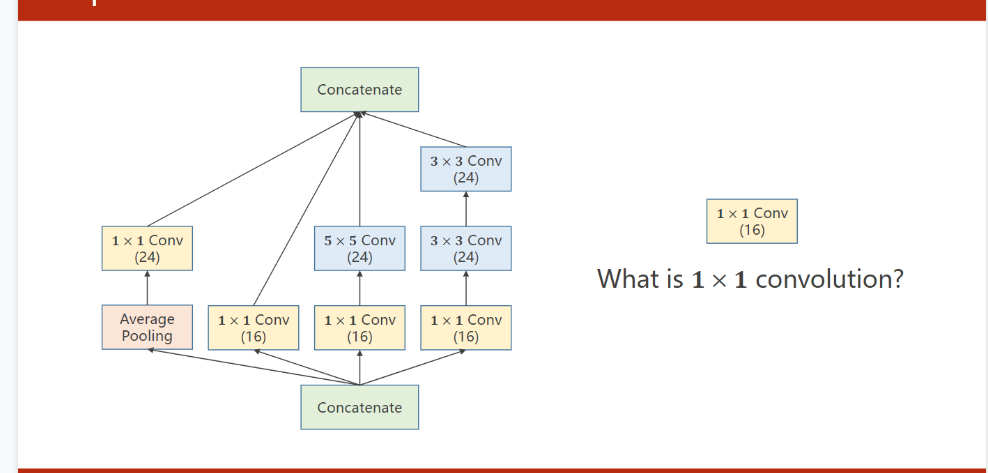

1*1卷积核的作用：
- 降低维度，减少计算量。比如64通道的输入，如果用5*5的卷积核把它改为16通道，需要h\*w\*5\*5\*64\*16计算量，而下面方法可以大大减少计算量：先用1\*1卷积核降到16通道，再用5\*5的进行特征提取，总计算量约为原来1/4
- 融合不同通道信息。因为单个卷积过程是64通道的输入与64通道卷积核作用生成一层结果，所以最终生成结果的每一层都融合了原始输入的所有通道信息

多途径的目的：

因为不同尺寸的卷积核能提取不同的特征，所以用多个途径分别处理输入，得到的最终结果再沿通道维度拼接(为保证能拼接，每个途径出来的结果除了通道数可以不同外，其它维度都应该保持相同)，就能得到更多特征


In [14]:
import torch
import torch.nn as nn

input = torch.randn(1, 1, 28, 28)


class InceptionA(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.net0 = torch.nn.Sequential(
            torch.nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            torch.nn.Conv2d(in_channels, 24, 1),
            torch.nn.ReLU(),
        )
        self.net1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, 16, 1), torch.nn.ReLU()
        )
        self.net2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, 16, 1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 24, 5, padding=2),
            torch.nn.ReLU(),
        )
        self.net3 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, 16, 1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 24, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(24, 24, 3, padding=1),
            torch.nn.ReLU(),
        )

    def forward(self, x):
        # 沿着通道维度把每条路径的结果拼接起来
        return torch.cat(
            [self.net0(x), self.net1(x), self.net2(x), self.net3(x)], dim=1
        )


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1, 10, kernel_size=5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            InceptionA(10),
            torch.nn.Conv2d(88, 20, kernel_size=5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            InceptionA(20),
        )
        self.fc = torch.nn.Linear(1408, 10)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        # x=torch.nn.Linear(1408,10)(x)这样是错误写法，
        # 因为这样网络在运行时每次调用forward都会创建一个新的全连接层，
        # 它的训练参数根本保存不下来，所以会出错，
        # 应该放到__init__中，每个model只调用一次__init__，
        # 所以训练参数跟随整个训练过程
        x = self.fc(x)
        return x


# 确定中间某一步的通道数
model = Net()
print(model(input).size(1))

10


In [15]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

batch_size = 64
# Compose,依次执行这几个操作
# Nomalize：把数据尽可能处理为均值为0，标准差为1，更利于神经网络训练的稳定性，
# 传元组是因为读入的图片可以有多通道，每个通道站一个位置
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)
# 从官网下载数据到本地，train表明是下载训练集还是测试集，transform：对文件进行预处理
train_dataset = datasets.MNIST(
    root="./mnist/", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(
    root="./mnist/", train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


model = Net()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
# 该函数可以完成
# 1.softmax(把最后得到的10个数转为概率，满足每个数>=0且和为1)，
# 2.取log
# 3.nllloss
criterion = torch.nn.CrossEntropyLoss()
# monetum:能够记忆历史梯度，并自动调节参数更新速度，
# 若某个参数连着朝一个方向更新了好几次，就加快它的更新速度
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)


def train():
    for inputs, target in train_loader:
        # 模型和输入必须在同一个设备
        inputs, target = inputs.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()


def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total += labels.size(0)
            # _存最大值，predicted存最大值的位置，均为一维，
            # torch.max对每行分别处理
            _, predicted = torch.max(outputs, dim=1)
            # 注意：tensor.sum()也是返回一个tensor，这是定义规定的
            # ==创建一个bool tensor，元素为每个比较结果，bool型，sum按照0/1统计
            correct += (predicted == labels).sum().item()
    print("accuracy on test set:%.2f %%" % (100 * correct / total))


for epoch in range(10):
    train()
    test()

accuracy on test set:96.41 %
accuracy on test set:97.40 %
accuracy on test set:97.48 %
accuracy on test set:98.12 %
accuracy on test set:98.42 %
accuracy on test set:98.58 %
accuracy on test set:98.59 %
accuracy on test set:98.68 %
accuracy on test set:98.81 %
accuracy on test set:98.74 %


Residual net思想

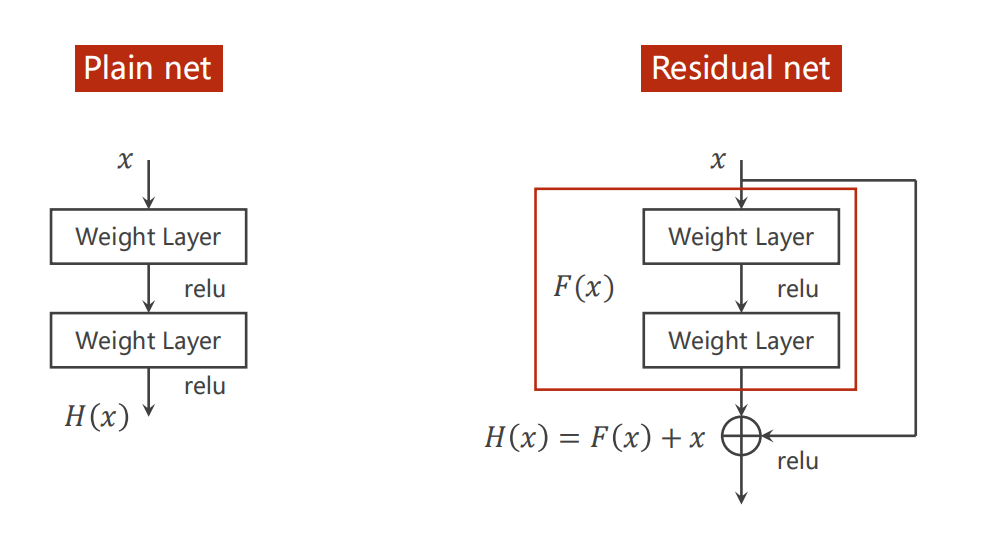

当训练层数增多时，会面临梯度消失问题，因为梯度计算的链式法则是不断乘积，所以如果每个梯度都小于1，那么层数过多后最后传到开始位置的梯度会特别小，训练效果变差，解决这一问题可以把训练层分出多个residual block(残差块)，块的开头记录进入数据x，块的结尾得到处理后的数据f(x)，最终块的输出设定为f(x)+x(为保证能相加，应该保持x和f(x)维度完全相同)，这样求梯度时就会往回传一个1，避免前面的梯度消失。

In [16]:
import torch.nn.functional as F


class ResidualBlock(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(channels, channels, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        y = self.net(x)
        # 这里的relu不是为了产生非线性，因为x+y已经是非线性，这里是一种设计选择，利用relu控制范围，也可以不加
        return F.relu(x + y)

In [ ]:
class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, 5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            ResidualBlock(16),
            torch.nn.Conv2d(16, 32, 5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            ResidualBlock(32),
        )
        self.fc = torch.nn.Linear(512, 10)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


model = Net()
print(model(input).size(1))

10


In [21]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

batch_size = 64
# Compose,依次执行这几个操作
# Nomalize：把数据尽可能处理为均值为0，标准差为1，更利于神经网络训练的稳定性，
# 传元组是因为读入的图片可以有多通道，每个通道站一个位置
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)
# 从官网下载数据到本地，train表明是下载训练集还是测试集，transform：对文件进行预处理
train_dataset = datasets.MNIST(
    root="./mnist/", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(
    root="./mnist/", train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


model = Net()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
# 该函数可以完成
# 1.softmax(把最后得到的10个数转为概率，满足每个数>=0且和为1)，
# 2.取log
# 3.nllloss
criterion = torch.nn.CrossEntropyLoss()
# monetum:能够记忆历史梯度，并自动调节参数更新速度，
# 若某个参数连着朝一个方向更新了好几次，就加快它的更新速度
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)


def train():
    for inputs, target in train_loader:
        # 模型和输入必须在同一个设备
        inputs, target = inputs.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()


def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total += labels.size(0)
            # _存最大值，predicted存最大值的位置，均为一维，
            # torch.max对每行分别处理
            _, predicted = torch.max(outputs, dim=1)
            # 注意：tensor.sum()也是返回一个tensor，这是定义规定的
            # ==创建一个bool tensor，元素为每个比较结果，bool型，sum按照0/1统计
            correct += (predicted == labels).sum().item()
    print("accuracy on test set:%.2f %%" % (100 * correct / total))


for epoch in range(10):
    train()
    test()

accuracy on test set:97.73 %
accuracy on test set:98.53 %
accuracy on test set:98.60 %
accuracy on test set:98.78 %
accuracy on test set:99.01 %
accuracy on test set:99.00 %
accuracy on test set:99.04 %
accuracy on test set:99.06 %
accuracy on test set:99.06 %
accuracy on test set:98.99 %
